# 05: Functional Group Analysis

This notebook handles:
- Classifying proteins by functional categories (Ion Channels, GPCRs, Transporters, etc.)
- Analyzing pLLPS patterns within functional groups
- Examining interaction patterns for specific functional classes

**Inputs:**
- `results/full_dataset.csv` - From notebook 01
- `results/string_interactions_matched.csv` - From notebook 02

**Outputs:**
- `results/functional_categories.csv` - Proteins with functional annotations
- `results/functional_group_stats.json` - Statistics per functional group
- Visualization plots

In [12]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import llps_functions as lf

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Previous Results

In [13]:
# Load data
df_full = lf.load_analysis_result('full_dataset', format='csv')
matched_df = lf.load_analysis_result('string_interactions_matched', format='csv')

print(f"\n📊 Loaded data:")
print(f"   Full dataset: {len(df_full)} proteins")
print(f"   Matched interactions: {len(matched_df)}")

✅ Loaded CSV from: results/full_dataset.csv (20366 rows)
✅ Loaded CSV from: results/string_interactions_matched.csv (84 rows)

📊 Loaded data:
   Full dataset: 20366 proteins
   Matched interactions: 84


## 2. Classify Proteins by Function

Apply functional classification to identify Ion Channels, GPCRs, Transporters, etc.

In [14]:
# Add functional categories
print("\n🔍 Classifying proteins by function...")

df_with_functions = lf.add_functional_categories(df_full)

print(f"\n✅ Classification complete")


🔍 Classifying proteins by function...
✅ Added functional categories
   Categories found: ['Enzyme', 'Ion Channel', 'Receptor', 'Receptor Tyrosine Kinase', 'Transporter']

✅ Classification complete


In [15]:
# Count proteins per category
category_columns = [col for col in df_with_functions.columns if col.startswith('Is_')]
category_counts = {}

for col in category_columns:
    category_name = col.replace('Is_', '').replace('_', ' ')
    count = df_with_functions[col].sum()
    category_counts[category_name] = count

print("\n📊 Proteins per functional category:")
for category, count in sorted(category_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = count / len(df_with_functions) * 100
    print(f"   {category}: {count} ({percentage:.1f}%)")


📊 Proteins per functional category:
   Membrane: 6463 (31.7%)
   Receptor: 3180 (15.6%)
   Enzyme: 3016 (14.8%)
   Transporter: 572 (2.8%)
   Ion Channel: 397 (1.9%)
   Receptor Tyrosine Kinase: 65 (0.3%)


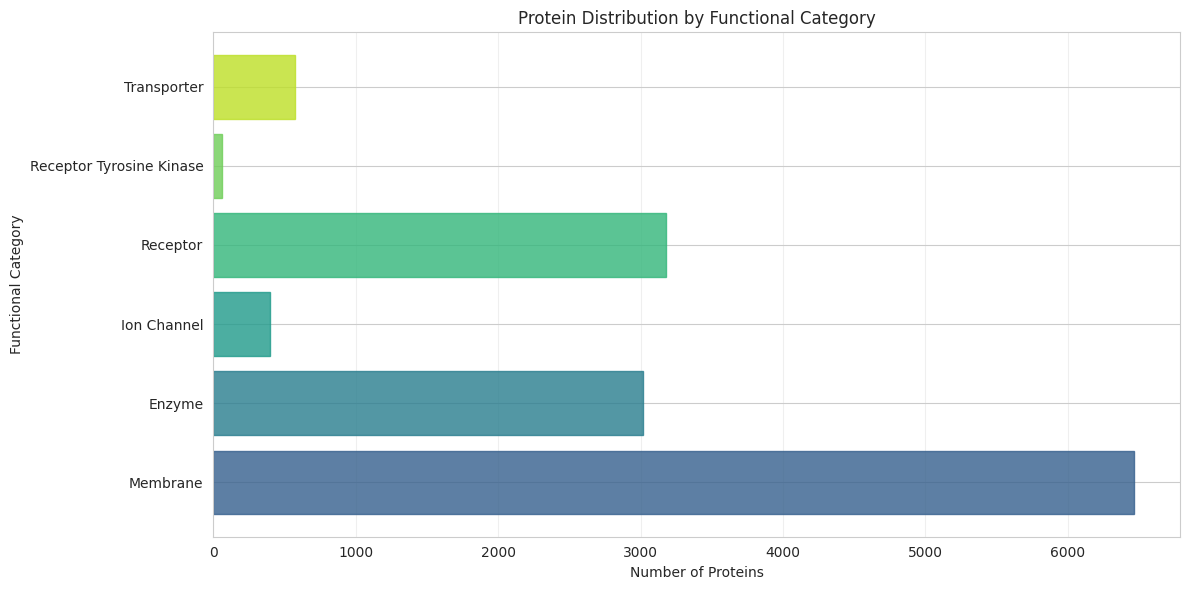


✅ Saved plot: results/functional_category_distribution.png


In [16]:
# Visualize category distribution
if category_counts:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    categories = list(category_counts.keys())
    counts = list(category_counts.values())
    
    bars = ax.barh(categories, counts, alpha=0.8, edgecolor='black')
    
    # Color bars by count
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(bars)))
    for bar, color in zip(bars, colors):
        bar.set_color(color)
    
    ax.set_xlabel('Number of Proteins')
    ax.set_ylabel('Functional Category')
    ax.set_title('Protein Distribution by Functional Category')
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('results/functional_category_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Saved plot: results/functional_category_distribution.png")

## 3. Analyze pLLPS Patterns by Functional Group

In [17]:
# Calculate statistics per functional group
functional_stats = {}

for col in category_columns:
    category_name = col.replace('Is_', '').replace('_', ' ')
    category_proteins = df_with_functions[df_with_functions[col]]
    
    if len(category_proteins) > 0:
        functional_stats[category_name] = {
            'count': len(category_proteins),
            'mean_pllps': category_proteins['p(LLPS)'].mean(),
            'median_pllps': category_proteins['p(LLPS)'].median(),
            'std_pllps': category_proteins['p(LLPS)'].std(),
            'high_pllps_count': (category_proteins['pLLPS_Class'] == 'High').sum(),
            'high_pllps_percentage': (category_proteins['pLLPS_Class'] == 'High').sum() / len(category_proteins) * 100
        }

# Display as DataFrame
stats_df = pd.DataFrame(functional_stats).T
stats_df = stats_df.sort_values('mean_pllps', ascending=False)

print("\n📊 pLLPS Statistics by Functional Group:")
display(stats_df)


📊 pLLPS Statistics by Functional Group:


,count,mean_pllps,median_pllps,std_pllps,high_pllps_count,high_pllps_percentage
Enzyme,3016.0,0.463395,0.340,0.319887,869.0,28.812997
Receptor Tyrosine Kinase,65.0,0.435077,0.350,0.262340,13.0,20.000000
Ion Channel,397.0,0.426851,0.280,0.304304,97.0,24.433249
Receptor,3180.0,0.405050,0.255,0.318938,755.0,23.742138
Membrane,6463.0,0.381550,0.250,0.296441,1287.0,19.913353
Transporter,572.0,0.302378,0.210,0.231152,52.0,9.090909


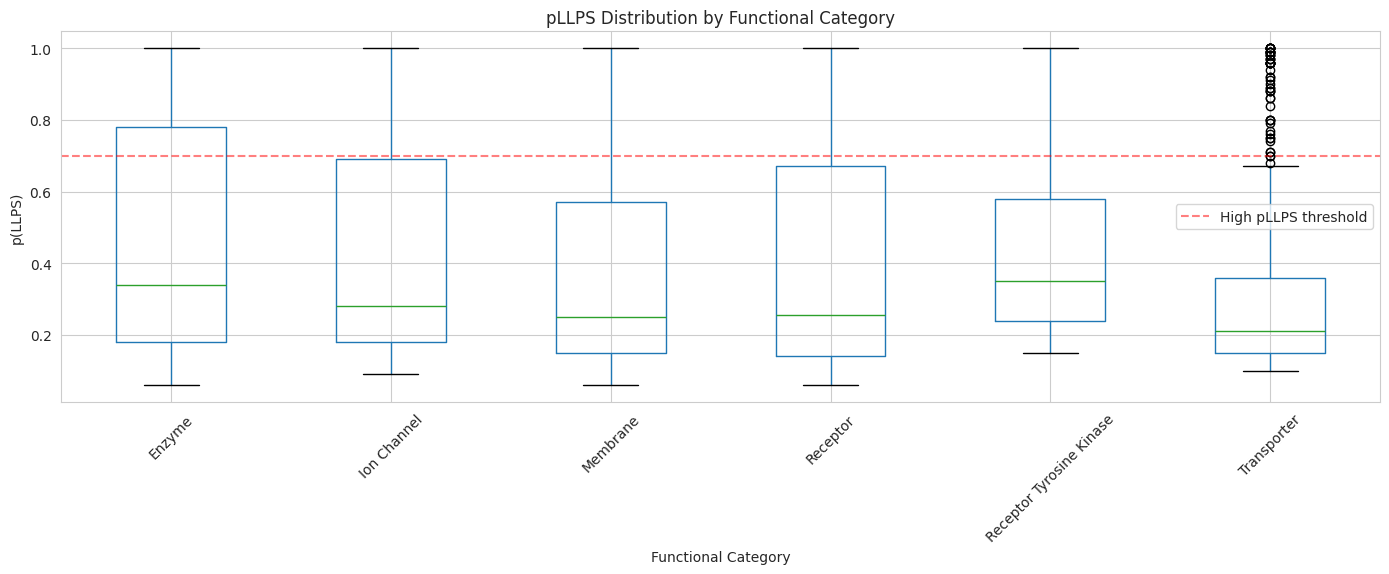


✅ Saved plot: results/pllps_by_functional_group.png


In [18]:
# Visualize pLLPS distribution by functional group
if len(category_columns) > 0:
    # Prepare data for plotting
    plot_data = []
    
    for col in category_columns:
        category_name = col.replace('Is_', '').replace('_', ' ')
        category_proteins = df_with_functions[df_with_functions[col]]
        
        if len(category_proteins) > 0:
            for pllps in category_proteins['p(LLPS)'].dropna():
                plot_data.append({
                    'Category': category_name,
                    'pLLPS': pllps
                })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create box plot
    fig, ax = plt.subplots(figsize=(14, 6))
    
    plot_df.boxplot(column='pLLPS', by='Category', ax=ax, rot=45)
    ax.axhline(0.7, color='red', linestyle='--', alpha=0.5, label='High pLLPS threshold')
    ax.set_xlabel('Functional Category')
    ax.set_ylabel('p(LLPS)')
    ax.set_title('pLLPS Distribution by Functional Category')
    ax.legend()
    plt.suptitle('')  # Remove default title
    
    plt.tight_layout()
    plt.savefig('results/pllps_by_functional_group.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Saved plot: results/pllps_by_functional_group.png")

## 4. Interaction Patterns by Functional Group

In [19]:
# Analyze interactions within and between functional groups
print("\n🔗 Analyzing interaction patterns by functional group...")

# Create protein ID to category mapping
protein_categories = {}
for idx, row in df_with_functions.iterrows():
    if pd.notna(row.get('Entry')):
        categories = []
        for col in category_columns:
            if row[col]:
                categories.append(col.replace('Is_', '').replace('_', ' '))
        if categories:
            protein_categories[row['Entry']] = categories

print(f"   Mapped {len(protein_categories)} proteins to functional categories")

# Count within-group and between-group interactions
interaction_matrix = {}

for category1 in category_counts.keys():
    interaction_matrix[category1] = {}
    for category2 in category_counts.keys():
        interaction_matrix[category1][category2] = 0

# Count interactions
complete_pairs = matched_df[matched_df['both_in_dataset']]

for idx, row in complete_pairs.iterrows():
    p1 = row['protein1']
    p2 = row['protein2']
    
    if p1 in protein_categories and p2 in protein_categories:
        cats1 = protein_categories[p1]
        cats2 = protein_categories[p2]
        
        for cat1 in cats1:
            for cat2 in cats2:
                interaction_matrix[cat1][cat2] += 1

# Convert to DataFrame
interaction_matrix_df = pd.DataFrame(interaction_matrix)

print("\n📋 Interaction Matrix (rows interact with columns):")
display(interaction_matrix_df)


🔗 Analyzing interaction patterns by functional group...
   Mapped 9574 proteins to functional categories

📋 Interaction Matrix (rows interact with columns):


,Membrane,Enzyme,Ion Channel,Receptor,Receptor Tyrosine Kinase,Transporter
Membrane,2,2,0,2,0,0
Enzyme,1,9,0,6,0,0
Ion Channel,0,0,0,0,0,0
Receptor,2,3,0,6,0,0
Receptor Tyrosine Kinase,0,0,0,0,0,0
Transporter,0,0,0,0,0,0


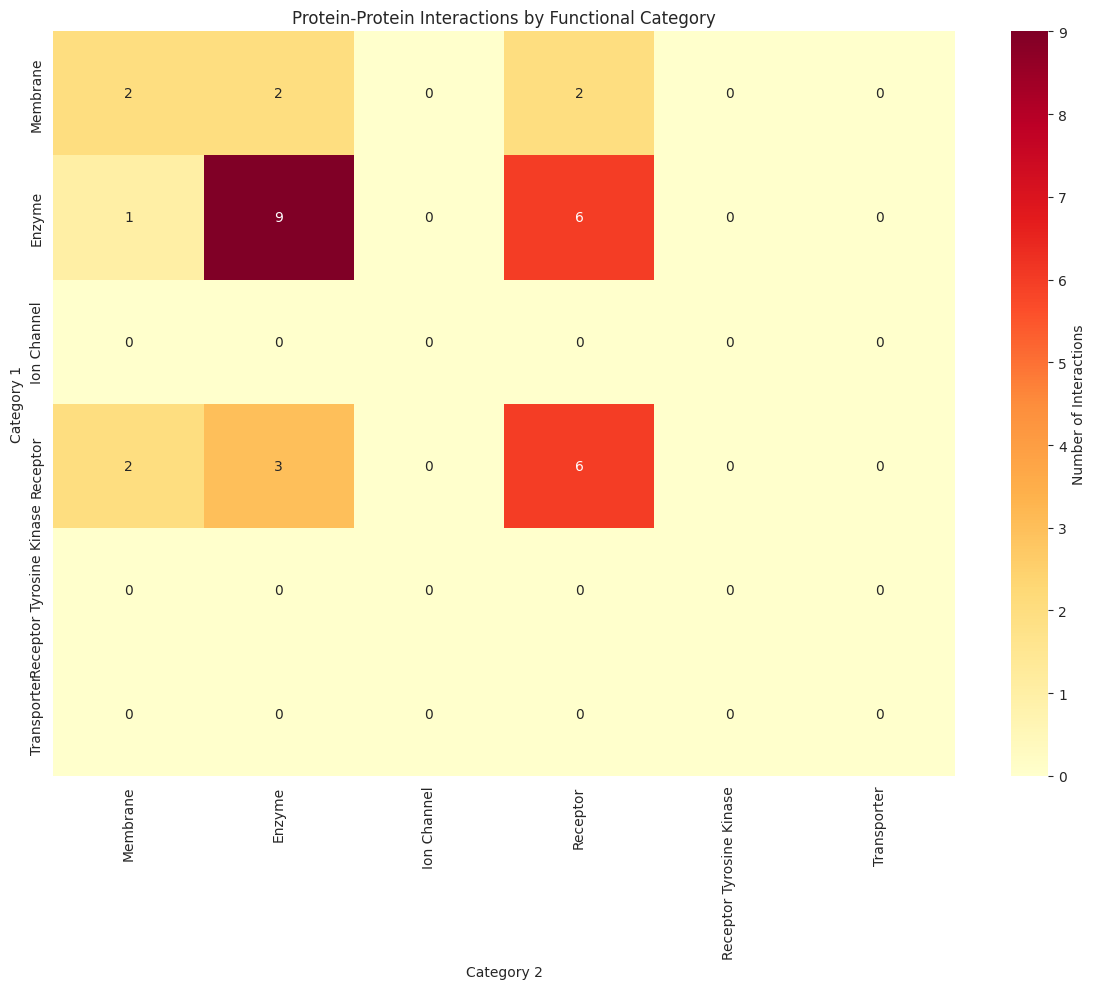


✅ Saved plot: results/functional_group_interaction_matrix.png


In [20]:
# Visualize interaction matrix as heatmap
if not interaction_matrix_df.empty:
    fig, ax = plt.subplots(figsize=(12, 10))
    
    sns.heatmap(interaction_matrix_df, annot=True, fmt='d', cmap='YlOrRd', 
                ax=ax, cbar_kws={'label': 'Number of Interactions'})
    ax.set_title('Protein-Protein Interactions by Functional Category')
    ax.set_xlabel('Category 2')
    ax.set_ylabel('Category 1')
    
    plt.tight_layout()
    plt.savefig('results/functional_group_interaction_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Saved plot: results/functional_group_interaction_matrix.png")

## 5. Save Results

In [21]:
# Save classified proteins
lf.save_analysis_result(df_with_functions, 'functional_categories', format='csv')

# Save statistics
lf.save_analysis_result(functional_stats, 'functional_group_stats', format='json')

# Save interaction matrix
if not interaction_matrix_df.empty:
    lf.save_analysis_result(interaction_matrix_df, 'functional_group_interaction_matrix', format='csv')

print("\n" + "="*60)
print("✅ All results saved successfully!")
print("="*60)

✅ Saved CSV to: results/functional_categories.csv
✅ Saved JSON to: results/functional_group_stats.json
✅ Saved CSV to: results/functional_group_interaction_matrix.csv

✅ All results saved successfully!


In [11]:
# List saved files
lf.list_saved_results()

📁 Found 16 result files in results:
   - classification_summary.json (0.4 KB)
   - communities_analysis.csv (2.7 KB)
   - full_dataset.csv (18.7 MB)
   - functional_categories.csv (19.4 MB)
   - functional_group_interactions.csv (0.4 KB)
   - functional_group_pllps_analysis.csv (0.3 KB)
   - functional_group_stats.json (1.3 KB)
   - high_pllps_clusters.csv (2.6 KB)
   - high_pllps_hubs.csv (16.0 KB)
   - high_pllps_proteins.csv (6.1 MB)
   - high_pllps_proteins_connectivity.csv (23.6 KB)
   - hub_analysis_full.csv (311.4 KB)
   - llps_driven_clusters.csv (0.2 KB)
   - membrane_proteins.csv (6.9 MB)
   - membrane_proteins_full.csv (9.9 MB)
   - string_interactions_raw.csv (18.5 KB)


['classification_summary.json',
 'communities_analysis.csv',
 'full_dataset.csv',
 'functional_categories.csv',
 'functional_group_interactions.csv',
 'functional_group_pllps_analysis.csv',
 'functional_group_stats.json',
 'high_pllps_clusters.csv',
 'high_pllps_hubs.csv',
 'high_pllps_proteins.csv',
 'high_pllps_proteins_connectivity.csv',
 'hub_analysis_full.csv',
 'llps_driven_clusters.csv',
 'membrane_proteins.csv',
 'membrane_proteins_full.csv',
 'string_interactions_raw.csv']

## Summary

✅ **Completed:**
1. Classified proteins by functional categories
2. Analyzed pLLPS patterns within functional groups
3. Examined interaction patterns between functional categories
4. Generated visualizations
5. Saved all results to `results/` directory

**Next step:** Run `06_visualization_summary.ipynb` for comprehensive summary visualizations.